## Health Informer System Architecture

This diagram illustrates the end-to-end RAG pipeline, from data ingestion through user query processing to cited response generation. 

The system uses HyDE (Hypothetical Document Embeddings) to bridge the vocabulary gap between normal-language user queries and clinical, abstracted-language PubMed studies.

In [5]:
import os
os.makedirs('figures', exist_ok=True)

In [6]:
import os
from pathlib import Path


if Path('evaluation/results').exists():
    pass  
elif Path('../evaluation/results').exists():
    os.chdir('..')
else:
    raise RuntimeError('Run this notebook from the HealthInformer project root')

print(f'Working directory: {os.getcwd()}')

Working directory: /Users/ashhad/HealthInformer


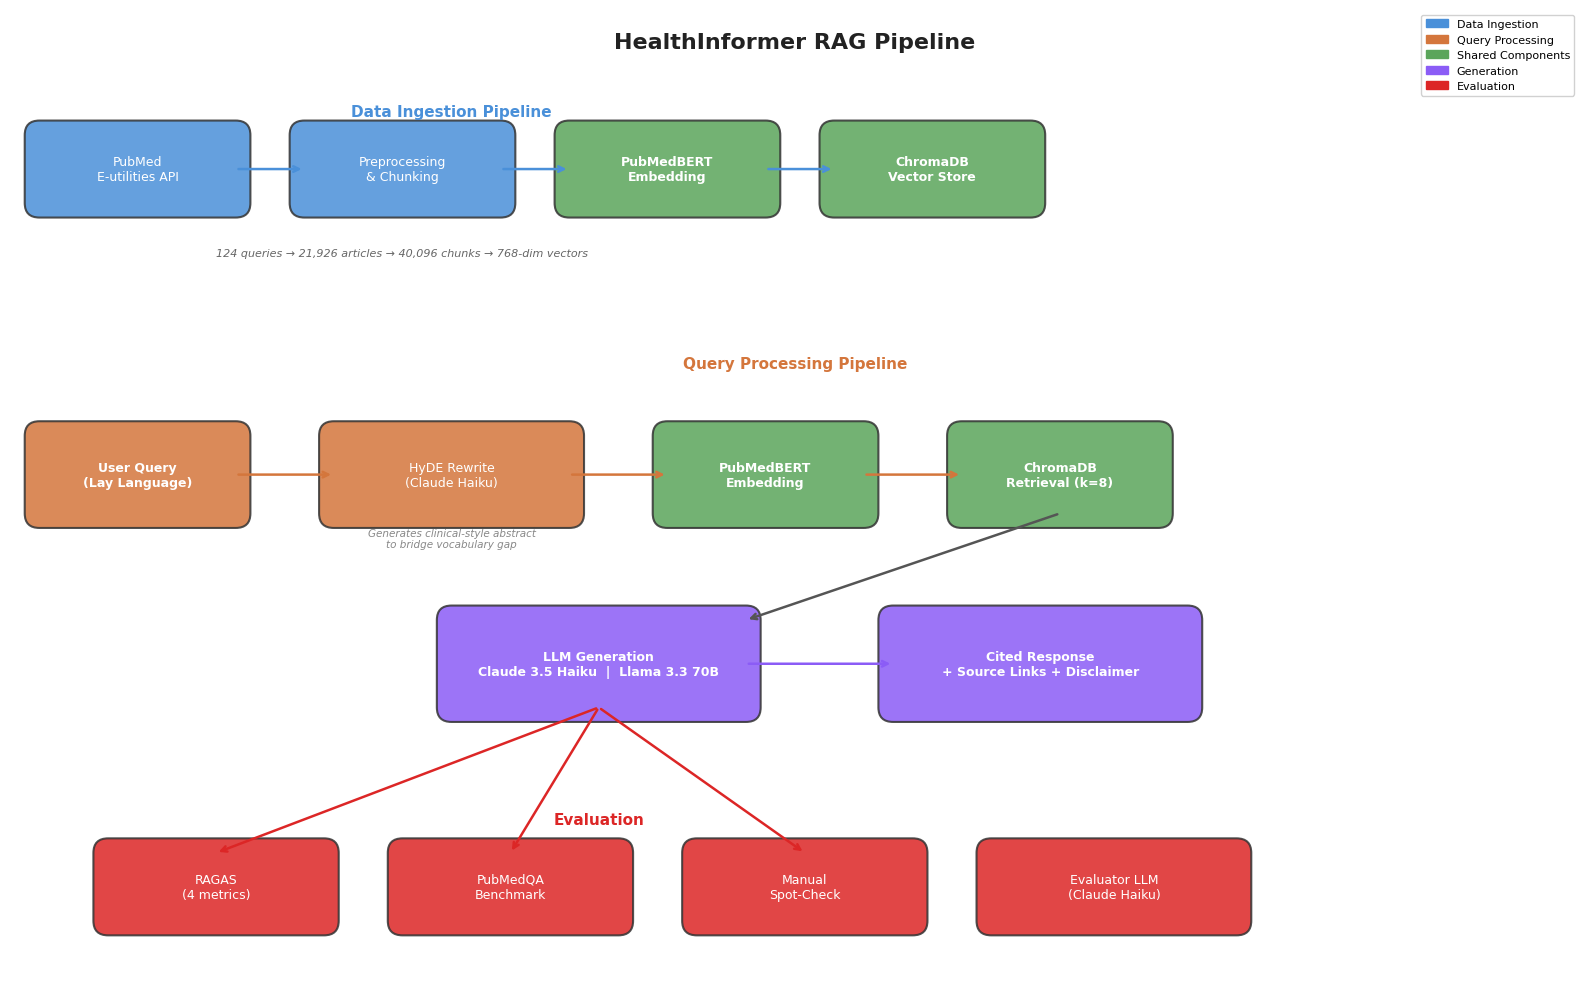

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('white')

# Colors
ingestion_color = '#4A90D9'
query_color = '#D4763C'
shared_color = '#5BA55B'
output_color = '#8B5CF6'

def draw_box(ax, x, y, w, h, text, color, fontsize=9, bold=False):
    box = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                                   facecolor=color, edgecolor='#333333', linewidth=1.5, alpha=0.85)
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, color='white', fontweight=weight, wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, color='#555555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))

# === Title ===
ax.text(8, 9.6, 'HealthInformer RAG Pipeline', ha='center', fontsize=16, fontweight='bold', color='#222222')

# === Data Ingestion Path (top) ===
ax.text(4.5, 8.9, 'Data Ingestion Pipeline', ha='center', fontsize=11, fontweight='bold', color=ingestion_color)

draw_box(ax, 0.3, 8.0, 2.0, 0.7, 'PubMed\nE-utilities API', ingestion_color)
draw_box(ax, 3.0, 8.0, 2.0, 0.7, 'Preprocessing\n& Chunking', ingestion_color)
draw_box(ax, 5.7, 8.0, 2.0, 0.7, 'PubMedBERT\nEmbedding', shared_color, bold=True)
draw_box(ax, 8.4, 8.0, 2.0, 0.7, 'ChromaDB\nVector Store', shared_color, bold=True)

draw_arrow(ax, 2.3, 8.35, 3.0, 8.35, ingestion_color)
draw_arrow(ax, 5.0, 8.35, 5.7, 8.35, ingestion_color)
draw_arrow(ax, 7.7, 8.35, 8.4, 8.35, ingestion_color)

# Corpus stats
ax.text(4.0, 7.45, '124 queries → 21,926 articles → 40,096 chunks → 768-dim vectors',
        ha='center', fontsize=8, color='#666666', style='italic')

# === Query Path (bottom) ===
ax.text(8, 6.3, 'Query Processing Pipeline', ha='center', fontsize=11, fontweight='bold', color=query_color)

draw_box(ax, 0.3, 4.8, 2.0, 0.8, 'User Query\n(Lay Language)', query_color, bold=True)
draw_box(ax, 3.3, 4.8, 2.4, 0.8, 'HyDE Rewrite\n(Claude Haiku)', query_color)
draw_box(ax, 6.7, 4.8, 2.0, 0.8, 'PubMedBERT\nEmbedding', shared_color, bold=True)
draw_box(ax, 9.7, 4.8, 2.0, 0.8, 'ChromaDB\nRetrieval (k=8)', shared_color, bold=True)

draw_arrow(ax, 2.3, 5.2, 3.3, 5.2, query_color)
draw_arrow(ax, 5.7, 5.2, 6.7, 5.2, query_color)
draw_arrow(ax, 8.7, 5.2, 9.7, 5.2, query_color)

# HyDE annotation
ax.text(4.5, 4.45, 'Generates clinical-style abstract\nto bridge vocabulary gap',
        ha='center', fontsize=7.5, color='#888888', style='italic')

# === Generation Path ===
draw_box(ax, 4.5, 2.8, 3.0, 0.9, 'LLM Generation\nClaude 3.5 Haiku  |  Llama 3.3 70B',
         output_color, fontsize=9, bold=True)
draw_box(ax, 9.0, 2.8, 3.0, 0.9, 'Cited Response\n+ Source Links + Disclaimer',
         output_color, bold=True)

# Arrow from retrieval down to generation
draw_arrow(ax, 10.7, 4.8, 7.5, 3.7, '#555555')
# Arrow from generation to response
draw_arrow(ax, 7.5, 3.25, 9.0, 3.25, output_color)

# === Evaluation Path ===
ax.text(6.0, 1.6, 'Evaluation', ha='center', fontsize=11, fontweight='bold', color='#DC2626')

draw_box(ax, 1.0, 0.6, 2.2, 0.7, 'RAGAS\n(4 metrics)', '#DC2626')
draw_box(ax, 4.0, 0.6, 2.2, 0.7, 'PubMedQA\nBenchmark', '#DC2626')
draw_box(ax, 7.0, 0.6, 2.2, 0.7, 'Manual\nSpot-Check', '#DC2626')
draw_box(ax, 10.0, 0.6, 2.5, 0.7, 'Evaluator LLM\n(Claude Haiku)', '#DC2626')

draw_arrow(ax, 6.0, 2.8, 2.1, 1.3, '#DC2626')
draw_arrow(ax, 6.0, 2.8, 5.1, 1.3, '#DC2626')
draw_arrow(ax, 6.0, 2.8, 8.1, 1.3, '#DC2626')

# Legend
legend_items = [
    mpatches.Patch(color=ingestion_color, label='Data Ingestion'),
    mpatches.Patch(color=query_color, label='Query Processing'),
    mpatches.Patch(color=shared_color, label='Shared Components'),
    mpatches.Patch(color=output_color, label='Generation'),
    mpatches.Patch(color='#DC2626', label='Evaluation'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('figures/system_architecture.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()



### Key Design Decision: HyDE Retrieval

Our original pipeline of having standard embedding similarity between lay-language queries (e.g., *"What helps with diabetes?"*) and clinical PubMed abstracts performed poorly, only 28% of retrieved chunks were relevant. 

**HyDE (Hypothetical Document Embeddings)** 
We use HyDE, that uses Claude Haiku, to first rewrite the user query as a clinical-style abstract (to match the PubMED language). It then embeds that abstract for retrieval. This improved relevant chunk retrieval from 28% to 66%, and was the largest improvement to system performance.